In [1]:
### We will try to fit 4 Optical Depth Spectra from the hfs OH lines:
# We will keep the FWHM and center velocity as two free parameters,
# Then we will let the amplitudes vary per Gaussian.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import ascii

from lmfit import Model, minimize, Parameters, report_fit
from lmfit.models import GaussianModel

In [3]:
# Have to change error to be on -baseline- region.
def ew(x,y, lower=0, upper=10):
    """Equivalent width calculation.
    This error is currently overestimated, please disregard it!"""
    delta = abs(x[0]-x[1])
    idx = np.where((x >= lower) & (x <= upper))
    integral = np.sum(y[idx]*delta)
    error = rms(x,y, lower=lower, upper=upper)*np.sqrt(len(idx[0]))
    return integral, error

def rms(x,y, lower=-20, upper=0):
    """Return the rms in a baseline region."""
    idx = np.where((x >= lower) & (x <= upper))
    return np.std(y[idx])

def gauss(x, amp, cen, sigma):
    """Gaussian lineshape."""
    return amp * np.exp(-(x-cen)**2 / (2.*sigma**2))

def objective(params, x, data):
    """Calculate total residual for fits of Gaussians to several data sets."""
    ndata, _ = data.shape
    resid = 0.0*data[:]

    # make residual per data set
    for i in range(ndata):
        resid[i, :] = data[i, :] - gauss_dataset(params, i, x)

    # now flatten this to a 1D array, as minimize() needs
    return resid.flatten()

In [4]:
# how to get errors from the model:
# dely = result.eval_uncertainty(sigma=3)

### Here we will load and plot W3 ISR5.

In [5]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
ohsof = ascii.read('OH_data_deltav_0p1/W3IRS5_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= -30) & (VelSof <= 0))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W3 IRS5:
oh671 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=808)
oh651 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh121 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh201 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']

# Choose velocity range.
igood67 = np.where((vel67 >= -30) & (vel67 <= 0.3))
igood65 = np.where((vel65 >= -30) & (vel65 <= 0))
igood12 = np.where((vel12 >= -30) & (vel12 <= 0))
igood20 = np.where((vel20 >= -30) & (vel20 <= 0))

# Choose a continuum rang to calculate Tc.
igood67c = np.where((vel67 >= -130) & (vel67 <= -70))
igood65c = np.where((vel65 >= -130) & (vel65 <= -70))
igood12c = np.where((vel12 >= -130) & (vel12 <= -70))
igood20c = np.where((vel20 >= -130) & (vel20 <= -70))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]

In [13]:
vel67[1]-vel67[0]

0.5

In [6]:
# What is the continuum temperature (K) for 1667?
Tc67

5118.5625

In [7]:
# Create a data array to hold all the spectra.
data = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
data = np.array(data)

In [8]:
# Perform a Gaussian fit around the center velocity of the identified clouds:

# How many Gaussians are we going to use?
def gauss_dataset(params, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    amp1 = params[f'amp1_{i+1}']
    cen1 = params[f'cen1_{i+1}']
    sig1 = params[f'sig1_{i+1}']
    
    ### Add additional Gaussians here:
    #amp2 = params[f'amp2_{i+1}']
    #cen2 = params[f'cen2_{i+1}']
    #sig2 = params[f'sig2_{i+1}']
    #amp3 = params[f'amp3_{i+1}']
    #cen3 = params[f'cen3_{i+1}']
    #sig3 = params[f'sig3_{i+1}']
    
    return gauss(x, amp1, cen1, sig1)# + gauss(x, amp2, cen2, sig2) + gauss(x, amp3, cen3, sig3)# + gauss(x, amp4, cen4, sig4) + gauss(x, amp5, cen5, sig5)

# Create the fitters:
fit_params = Parameters()
for iy, y in enumerate(data):
    # First Gaussian
    fit_params.add(f'amp1_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen1_{iy+1}', value=-22, min=-25, max=-20)
    fit_params.add(f'sig1_{iy+1}', value=0.5, min=0.01, max=2.0)
    
    ### If we had multiple components:
    # Second Gaussian
    #fit_params.add(f'amp2_{iy+1}', value=0, min=-5, max=5)
    #fit_params.add(f'cen2_{iy+1}', value=60, min=50, max=69)
    #fit_params.add(f'sig2_{iy+1}', value=0.5, min=0.01, max=2.0)
     # Third Gaussian
    #fit_params.add(f'amp3_{iy+1}', value=0, min=-5, max=5)
    #fit_params.add(f'cen3_{iy+1}', value=57, min=50, max=69)
    #fit_params.add(f'sig3_{iy+1}', value=0.5, min=0.01, max=2.0)

# Set all FWHM, center to be the same in each gaussian fit per spectrum:
for iy in (2,3,4):
    # First Gaussian
    fit_params[f'sig1_{iy}'].expr = 'sig1_1'
    fit_params[f'cen1_{iy}'].expr = 'cen1_1'
    
    ### If we had multiple components:
    # Second Gaussian
    #fit_params[f'sig2_{iy}'].expr = 'sig2_1'
    #fit_params[f'cen2_{iy}'].expr = 'cen2_1'
    # Thid Gaussian
    #fit_params[f'sig3_{iy}'].expr = 'sig3_1'
    #fit_params[f'cen3_{iy}'].expr = 'cen3_1'

In [9]:
# Perform a fit:
out = minimize(objective, fit_params, args=(vel67, data))
report_fit(out.params)

[[Variables]]
    amp1_1: -0.08215222 +/- 0.00305045 (3.71%) (init = 0)
    cen1_1: -21.0243023 +/- 0.01535200 (0.07%) (init = -22)
    sig1_1:  0.34710727 +/- 0.01188878 (3.43%) (init = 0.5)
    amp1_2: -0.04950124 +/- 0.00289762 (5.85%) (init = 0)
    cen1_2: -21.0243023 +/- 0.01535200 (0.07%) == 'cen1_1'
    sig1_2:  0.34710727 +/- 0.01188878 (3.43%) == 'sig1_1'
    amp1_3: -0.00456748 +/- 0.00280756 (61.47%) (init = 0)
    cen1_3: -21.0243023 +/- 0.01535200 (0.07%) == 'cen1_1'
    sig1_3:  0.34710727 +/- 0.01188878 (3.43%) == 'sig1_1'
    amp1_4: -0.01874232 +/- 0.00281998 (15.05%) (init = 0)
    cen1_4: -21.0243023 +/- 0.01535200 (0.07%) == 'cen1_1'
    sig1_4:  0.34710727 +/- 0.01188878 (3.43%) == 'sig1_1'
[[Correlations]] (unreported correlations are < 0.100)
    C(amp1_1, sig1_1) = +0.3914
    C(sig1_1, amp1_2) = +0.2483


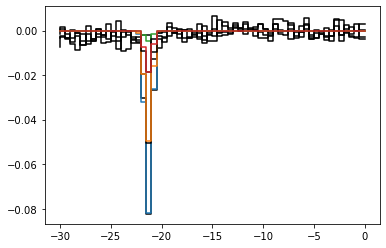

In [10]:
plt.figure()
for i in range(4):
    y_fit = gauss_dataset(out.params, i, vel67)
    plt.step(vel67, data[i, :], 'k', vel67, y_fit, '-')
    
# Get the best fit for plotting:
y_fit67 = gauss_dataset(out.params, 0, vel67)
y_fit65 = gauss_dataset(out.params, 1, vel65)
y_fit12 = gauss_dataset(out.params, 2, vel12)
y_fit20 = gauss_dataset(out.params, 3, vel20)

Text(0.5, 1.0, 'W3 IRS5')

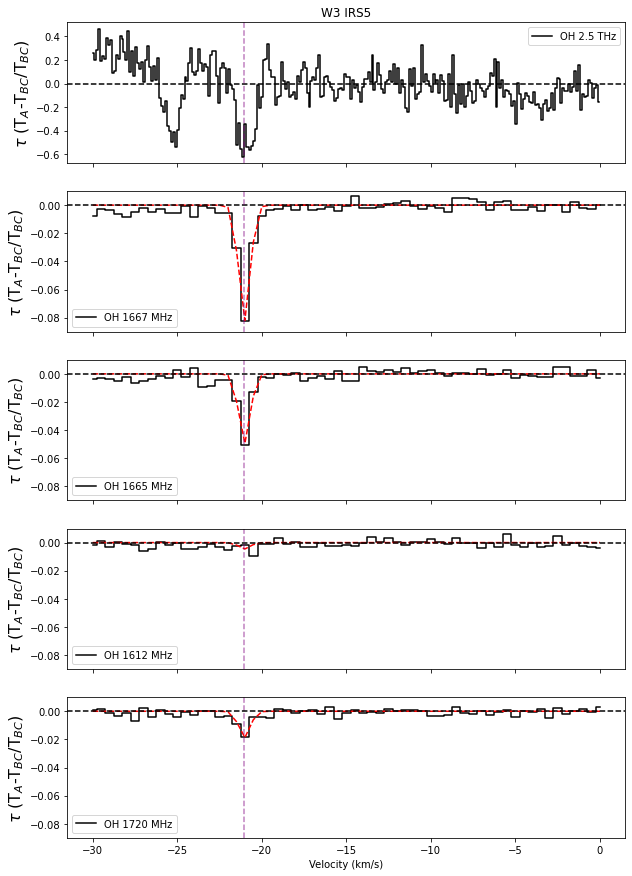

In [11]:
# Continuum Temperature for W3 IRS5 is 7.8K

# Plot the data:
fig, axs = plt.subplots(5, figsize=(10, 15), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/7.8), 'k', label='OH 2.5 THz', where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[0].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[0].legend(loc='best')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].plot(vel67, y_fit67, color='r', ls='dashed')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[1].set_ylim([-0.09, 0.01])
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[1].legend(loc='best')

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].plot(vel65, y_fit65, color='r', ls='dashed')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].set_ylim([-0.09, 0.01])
axs[2].legend(loc='best')

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].plot(vel12, y_fit12, color='r', ls='dashed')
axs[3].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[3].axhline(0, color='k', ls='dashed')
axs[3].set_ylim([-0.09, 0.01])
axs[3].legend(loc='best')

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].plot(vel20, y_fit20, color='r', ls='dashed')
axs[4].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].set_ylim([-0.09, 0.01])
axs[4].legend(loc='best')

plt.xlabel('Velocity (km/s)')
#fig.savefig("W49N_ThreeComponent.png", format='png')
axs[0].set_title('W3 IRS5')

In [12]:
# For default bounds, add upper and lower on other calls:

EWSofiaW51 = ew(VelSof, TaSof/8, upper = -20, lower = -23)
EW67W51 = ew(vel67, (Ta67-Tc67)/Tc67, upper = -20, lower = -23)
EW65W51 = ew(vel65, (Ta65-Tc65)/Tc65, upper = -20, lower = -23)
EW12W51 = ew(vel12, (Ta12-Tc12)/Tc12, upper = -20, lower = -23)
EW20W51 = ew(vel20, (Ta20-Tc20)/Tc20, upper = -20, lower = -23)

print("Central Velocity:" + str(out.params['cen1_1'].value))
print("Equivalent Width + Error (error is currently overestimated)")
print(EWSofiaW51)
print(EW67W51)
print(EW65W51)
print(EW12W51)
print(EW20W51)

Central Velocity:-21.024302324248374
Equivalent Width + Error (error is currently overestimated)
(-0.531302233357432, 1.4870949636882003)
(-0.080337764203817, 0.0696840724184164)
(-0.05069806417517921, 0.041302503780093876)
(-0.011709807113296708, 0.0074984743722557165)
(-0.021123228764038188, 0.015001417219204165)


In [ ]:
# Now we will use the updated spectra:
# Velocity Resolution of previous spectra: 0.5 km/s
# Velocity Resolution of new spectra: 

In [15]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
ohsof = ascii.read('OH_data_deltav_0p1/W3IRS5_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= -30) & (VelSof <= 0))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W3 IRS5:
oh671 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh3_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'])
oh651 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh2_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],)
oh121 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh201 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']

# Choose velocity range.
igood67 = np.where((vel67 >= -30) & (vel67 <= 0.3))
igood65 = np.where((vel65 >= -30) & (vel65 <= 0))
igood12 = np.where((vel12 >= -30) & (vel12 <= 0))
igood20 = np.where((vel20 >= -30) & (vel20 <= 0))

# Choose a continuum rang to calculate Tc.
igood67c = np.where((vel67 >= -130) & (vel67 <= -70))
igood65c = np.where((vel65 >= -130) & (vel65 <= -70))
igood12c = np.where((vel12 >= -130) & (vel12 <= -70))
igood20c = np.where((vel20 >= -130) & (vel20 <= -70))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]

InconsistentTableError: 
ERROR: Unable to guess table format with the guesses listed below:
Reader:FastBasic fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)']
Reader:FastBasic delimiter: '|' fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)'] quotechar: '"'
Reader:FastBasic delimiter: '|' fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)'] quotechar: "'"
Reader:FastBasic delimiter: ',' fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)'] quotechar: '"'
Reader:FastBasic delimiter: ',' fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)'] quotechar: "'"
Reader:FastBasic delimiter: ' ' fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)'] quotechar: '"'
Reader:FastBasic delimiter: ' ' fast_reader: {'enable': True} fill_values: [('', '0')] names: ['VELO (km/s)', 'Ta (K)'] quotecha